# Laboratorio 2. Complejidad y búsqueda de hiperparámetros
### ISIS2611 · Aprendizaje de Máquina | Caso AlpesPlanck

**Integrantes:** (nombres completos y códigos)

**Grupo de entrega:** GL2

**Fecha límite:** 14 de septiembre, 20:00

---

> **Nota de trabajo (eliminar antes de entregar).** Este notebook se está desarrollando en dos
> tramos. Las secciones 1 a 4 (preparación y protocolo, regresión polinomial, curvas de validación
> y modelos regularizados) están implementadas, ejecutadas y justificadas. Las secciones 5 a 11
> siguen en estado de esqueleto: cada una conserva la celda de texto que explica *qué* hay que
> hacer y *por qué*, seguida de una celda de código con comentarios `# TODO`.
> Al cerrar el laboratorio hay que eliminar esta nota y las que aparezcan marcadas como
> *"Nota del esqueleto"*, para que el documento entregado se lea como un informe técnico.

## 0. Mapa del laboratorio y trazabilidad con la rúbrica

| Sección del notebook | Actividad del enunciado | Criterio de rúbrica | Peso |
|:---|:---|:---|:---:|
| 1. Configuración, datos y protocolo de evaluación | Preparación previa | Transversal, soporta todos | 0 % directo |
| 2. Regresión polinomial con GridSearchCV | Actividad 1 | Criterio 1 | 15 % |
| 3. Curvas de validación | Actividad 2 | Se evalúa dentro de los criterios 1 y 6 | incluido |
| 4. Ridge y Lasso | Actividad 3 | Criterio 2 | 15 % |
| 5. Polinomial regularizado | Actividad 4 | Criterio 3 | 10 % |
| 6. Tabla comparativa y selección del mejor modelo | Actividad 5 | Criterio 4 | 5 % |
| 7. Intervalos de confianza por bootstrapping | Actividad 6 | Criterio 5 | 10 % |
| 8. Análisis de resultados | Sección "Análisis de resultados" | Criterio 6 | 35 % |
| 9. Video explicativo | Actividad 7 | Criterio 7 | 5 % |
| 10. Uso de herramientas de IA generativa | Reglas del curso | Criterio 8 | 5 % |

La actividad 2 (curvas de validación) no tiene una fila propia en la rúbrica, pero es la evidencia
gráfica sobre la que se sostienen varias preguntas del análisis de resultados, que pesa 35 %. Por eso
se desarrolla como sección independiente y su interpretación se escribe en la sección 3.1.

---
## 1. Configuración, datos y protocolo de evaluación

Esta sección no aparece en la rúbrica, pero condiciona la validez de todo lo demás. Si la partición o
el esquema de validación están mal planteados, todos los números posteriores quedan invalidados aunque
el código corra sin errores.

### 1.1 Importación de librerías

Todas las dependencias se declaran en una sola celda, agrupadas por origen, para que el entorno pueda
reconstruirse leyendo un único bloque y para que el notebook se pueda reejecutar desde un kernel limpio
sin importaciones dispersas.

El conjunto de herramientas se limita a lo trabajado en las prácticas del curso: `pandas` y `numpy` para
manipulación, `matplotlib` y `seaborn` para visualización, y de `scikit-learn` los componentes vistos en
las prácticas 2, 4, 5 y 6 (`Pipeline`, `ColumnTransformer`, `SimpleImputer`, los escaladores,
`OneHotEncoder`, `PolynomialFeatures`, `LinearRegression`, `Ridge`, `Lasso`, `train_test_split`,
`KFold`, `GridSearchCV`, `validation_curve`, `resample` y las métricas de regresión).

Se fija además una constante `RANDOM_STATE` que se reutiliza en la partición, en el `KFold` y en el
remuestreo. Sin semilla fija los resultados cambian entre ejecuciones y las conclusiones del análisis
dejan de ser verificables por quien revise el notebook.

In [1]:
# === Manipulación de datos y visualización ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# === Partición, validación cruzada y búsqueda de hiperparámetros ===
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, validation_curve

# === Pipeline y transformadores ===
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PolynomialFeatures, OneHotEncoder,
)

# === Estimadores lineales ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# === Métricas ===
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Remuestreo, para los intervalos de confianza de la sección 7 ===
from sklearn.utils import resample

# === Semilla global reutilizada en partición, validación cruzada y bootstrap ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === Configuración de presentación ===
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5)})

print(f"Semilla global: RANDOM_STATE = {RANDOM_STATE}")

Semilla global: RANDOM_STATE = 42


### 1.2 Recuperación de la preparación realizada en el Laboratorio 1

El Laboratorio 2 continúa el caso del Laboratorio 1, por lo que no se repite la etapa de exploración:
se reutilizan las decisiones de limpieza y preparación ya justificadas. El archivo entregado vuelve a
ser el conjunto original, de modo que hay que reproducir las transformaciones determinísticas antes de
empezar a modelar.

Se recupera la preparación del modelo final del Laboratorio 1 (el "Modelo 2"), que consta de tres
bloques:

1. **Correcciones de calidad.** Conversión de `fecha` a tipo fecha; unificación de las 34 variantes de
   escritura de `sector_viento` a ocho sectores canónicos; corrección del error de escala en
   `presion_media` (6 registros con valores diez veces mayores); conversión a porcentaje de los valores
   de humedad registrados como proporción y recorte a 100; reemplazo del centinela `-9999` de
   `rafaga_min` por faltante; y valor absoluto en `rafaga_desv`, que por definición no puede ser negativa.
2. **Variables temporales.** `mes` y `estacion_anio` llegan con decenas de variantes de escritura y
   errores tipográficos, así que se descartan y el mes se reconstruye desde `fecha` como
   `mes_calendario`. El Modelo 2 del Laboratorio 1 se quedó solo con el mes, porque la estación es una
   agregación del mismo ciclo anual y aportaba información redundante.
3. **Variables de rango.** Para presión, humedad, viento y ráfaga se reemplaza cada par
   mínimo/máximo por su rango, que resume la variabilidad intradía en una sola variable y reduce la
   colinealidad entre las tres mediciones del mismo fenómeno.

Dos decisiones sobre faltantes merecen justificarse por separado:

- **La variable objetivo no se imputa.** Las filas sin `temp_max_manana` no aportan información
  supervisada, y rellenarlas equivaldría a inventar la respuesta que el modelo debe aprender. Se
  descartan antes de la partición.
- **Los faltantes de las predictoras sí se imputan, pero dentro del pipeline.** La imputación, el
  escalamiento y la codificación aprenden parámetros de los datos (medianas, medias, desviaciones,
  categorías), así que quedan dentro de los pipelines para que se ajusten únicamente con los datos de
  entrenamiento de cada pliegue de validación cruzada. Aplicarlas aquí produciría fuga de información.

In [2]:
# =====================================================================
# Funciones de limpieza y preparación heredadas del Laboratorio 1
# =====================================================================

# --- Normalización de texto y categorías ---

def normalizar_texto(serie):
    """Quita espacios sobrantes y unifica a minúsculas para poder mapear."""
    return serie.astype(str).str.strip().str.lower()


def normalizar_categoria(serie, mapa):
    """Lleva una categórica sucia a su forma canónica conservando los faltantes."""
    return normalizar_texto(serie.dropna()).map(mapa).reindex(serie.index)


# --- Mapa canónico de sectores de viento ---

sector_map = {
    "n": "N", "norte": "N", "north": "N",
    "s": "S", "sur": "S", "south": "S",
    "e": "E", "este": "E", "east": "E",
    "o": "O", "oeste": "O", "west": "O",
    "ne": "NE", "noreste": "NE", "northeast": "NE",
    "no": "NO", "noroeste": "NO", "northwest": "NO",
    "se": "SE", "sureste": "SE", "southeast": "SE",
    "so": "SO", "suroeste": "SO", "southwest": "SO",
}

# --- Correcciones de calidad ---

def corregir_dataset(df, formato_fecha):
    """Aplica las correcciones de calidad justificadas en el Laboratorio 1."""
    df = df.copy()
    df["fecha"] = pd.to_datetime(df["fecha"], format=formato_fecha, errors="coerce")
    df["sector_viento"] = normalizar_categoria(df["sector_viento"], sector_map)
    df.loc[df["presion_media"] > 2000, "presion_media"] /= 10   # error de escala en hPa
    df.loc[df["humedad_media"] <= 1, "humedad_media"] *= 100     # proporción -> porcentaje
    df.loc[df["humedad_min"] <= 1, "humedad_min"] *= 100
    df["humedad_min"] = df["humedad_min"].clip(upper=100)        # la humedad relativa no pasa de 100 %
    df.loc[df["rafaga_min"] == -9999, "rafaga_min"] = np.nan     # centinela -> faltante explícito
    df["rafaga_desv"] = df["rafaga_desv"].abs()                  # una desviación no es negativa
    return df


# --- Reconstrucción de la variable temporal ---

numero_a_mes = {
    1: "enero", 2: "febrero", 3: "marzo", 4: "abril",
    5: "mayo", 6: "junio", 7: "julio", 8: "agosto",
    9: "septiembre", 10: "octubre", 11: "noviembre", 12: "diciembre",
}


def agregar_temporales(df):
    """Reconstruye el mes desde `fecha` y descarta las columnas de texto sucias."""
    df = df.copy()
    df["mes_calendario"] = df["fecha"].dt.month.map(numero_a_mes)
    return df.drop(columns=["mes", "estacion_anio"])


# --- Ingeniería de características (Modelo 2 del Laboratorio 1) ---

grupos_min_max = {
    "presion": ("presion_min", "presion_max"),
    "humedad": ("humedad_min", "humedad_max"),
    "viento": ("viento_min", "viento_max"),
    "rafaga": ("rafaga_min", "rafaga_max"),
}


def construir_caracteristicas_m2(df):
    """Sustituye cada par mínimo/máximo por su rango y descarta lo redundante."""
    df = df.copy()
    for grupo, (col_min, col_max) in grupos_min_max.items():
        df[f"{grupo}_rango"] = df[col_max] - df[col_min]
    columnas_sustituidas = [c for par in grupos_min_max.values() for c in par]
    columnas_sustituidas += ["dia_del_anio", "direccion_viento"]
    return df.drop(columns=columnas_sustituidas)


# =====================================================================
# Aplicación de la preparación
# =====================================================================

target = "temp_max_manana"
columnas_excluir = ["fecha", "anio", target]

datos = pd.read_csv("data/Datos Lab 1.csv")
n_inicial = len(datos)

datos = corregir_dataset(datos, formato_fecha="%Y-%m-%d")
datos = agregar_temporales(datos)
datos = construir_caracteristicas_m2(datos)

# La variable objetivo no se imputa: una fila sin `temp_max_manana` no aporta
# información supervisada y contaminaría la validación cruzada y la evaluación.
n_sin_objetivo = int(datos[target].isna().sum())
datos = datos.dropna(subset=[target]).reset_index(drop=True)

X = datos.drop(columns=columnas_excluir)
y = datos[target]

# =====================================================================
# Verificaciones
# =====================================================================

print(f"Filas leídas:                {n_inicial}")
print(f"Filas sin variable objetivo: {n_sin_objetivo}  (descartadas, no se imputa el objetivo)")
print(f"X: {X.shape}    y: {y.shape}")

print(f"\nSectores de viento canónicos: {sorted(X['sector_viento'].dropna().unique())}")
print(f"Meses reconstruidos:          {X['mes_calendario'].nunique()}")

faltantes = X.isna().sum()
print(f"\nFaltantes por predictora (se imputan dentro del pipeline):")
print(faltantes[faltantes > 0].to_string())

print(f"\nDescriptivos de la variable objetivo:")
print(y.describe().to_string())

Filas leídas:                2576
Filas sin variable objetivo: 95  (descartadas, no se imputa el objetivo)
X: (2481, 17)    y: (2481,)

Sectores de viento canónicos: ['E', 'N', 'NE', 'NO', 'O', 'S', 'SE', 'SO']
Meses reconstruidos:          12

Faltantes por predictora (se imputan dentro del pipeline):
presion_media         71
presion_desv          80
humedad_media         72
humedad_desv          60
viento_media          85
viento_desv           69
rafaga_media          75
rafaga_desv           76
viento_norte          78
viento_este           60
registros_del_dia     74
sector_viento         67
mes_calendario        70
presion_rango        129
humedad_rango        161
viento_rango         164
rafaga_rango         140

Descriptivos de la variable objetivo:
count    2481.0000
mean       13.8633
std         9.2962
min       -15.2300
25%         7.3100
50%        14.3100
75%        20.4600
max        63.0500


### 1.3 Partición entrenamiento / test

Se conserva el protocolo del Laboratorio 1 para que las dos entregas sean comparables: 75 % de los datos
para entrenamiento, 25 % para test, con `random_state = 42`.

La partición se hace antes de cualquier transformación que aprenda parámetros de los datos, de modo que
imputación, escalamiento y codificación se ajusten exclusivamente con los datos de entrenamiento de cada
pliegue.

El conjunto de test queda reservado durante toda la búsqueda de hiperparámetros y la selección de
modelos: todas las decisiones de las secciones 2 a 6 se toman con validación cruzada sobre entrenamiento.

**Una limitación que conviene dejar anotada.** `train_test_split` con mezcla aleatoria no respeta la
estructura temporal de la serie. Días consecutivos, que son fuertemente dependientes entre sí, pueden
quedar repartidos entre entrenamiento y test, lo que hace que la estimación del error sea algo optimista
frente a un uso real en el que hay que predecir hacia el futuro. Se mantiene la partición aleatoria por
continuidad con el Laboratorio 1 y porque el objeto de este laboratorio es comparar complejidad y
regularización bajo un protocolo fijo, pero la comparación honesta con un esquema de validación temporal
queda señalada como limitación en el análisis de resultados.

Entrenamiento: (1860, 17)  |  Test: (621, 17)

y_train — media: 13.76 °C, desv: 9.36 °C
y_test  — media: 14.18 °C, desv: 9.10 °C

RMSE del modelo nulo (predecir la media de entrenamiento): 9.3596 °C


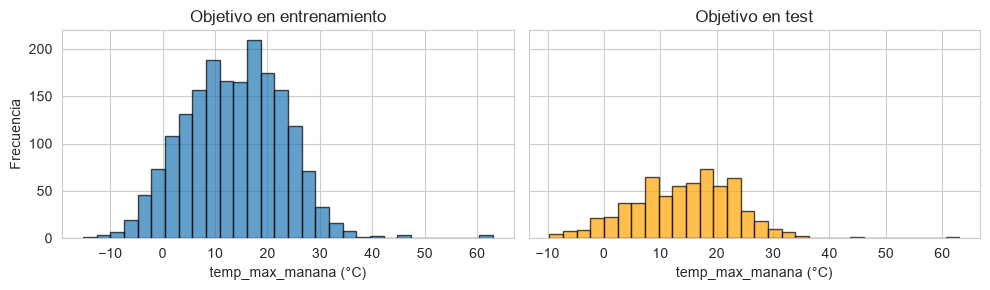

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\ny_train — media: {y_train.mean():.2f} °C, desv: {y_train.std():.2f} °C")
print(f"y_test  — media: {y_test.mean():.2f} °C, desv: {y_test.std():.2f} °C")

# Modelo nulo: predecir siempre la media de entrenamiento. Fija la escala contra
# la cual se debe leer cualquier RMSE posterior.
rmse_nulo = float(np.sqrt(((y_train - y_train.mean()) ** 2).mean()))
print(f"\nRMSE del modelo nulo (predecir la media de entrenamiento): {rmse_nulo:.4f} °C")

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
axes[0].hist(y_train, bins=30, edgecolor="k", alpha=0.7)
axes[0].set_title("Objetivo en entrenamiento")
axes[0].set_xlabel("temp_max_manana (°C)")
axes[0].set_ylabel("Frecuencia")
axes[1].hist(y_test, bins=30, edgecolor="k", alpha=0.7, color="orange")
axes[1].set_title("Objetivo en test")
axes[1].set_xlabel("temp_max_manana (°C)")
plt.tight_layout()
plt.show()

### 1.4 Protocolo de validación y métricas

Toda la selección de modelos y de hiperparámetros se hace con validación cruzada sobre el conjunto de
entrenamiento, con un **único** esquema reutilizado en todas las búsquedas. Usar el mismo objeto `KFold`
en las cuatro búsquedas garantiza que los modelos se comparen sobre exactamente las mismas particiones,
de modo que las diferencias de error no se deban a haber evaluado con pliegues distintos.

Se usa `KFold(n_splits=10, shuffle=True, random_state=42)`, la configuración trabajada en la práctica 6.
Con 1 860 observaciones de entrenamiento, diez pliegues dejan unas 186 observaciones por pliegue de
validación: suficiente para que cada estimación de error sea razonablemente estable, y a la vez
suficientes repeticiones para estimar la desviación estándar entre pliegues, que es la medida de
estabilidad que exige el enunciado. `shuffle=True` es necesario porque el archivo viene ordenado por
fecha; sin mezclar, cada pliegue sería un tramo temporal contiguo y quedaría dominado por la estación
del año.

Las tres métricas del enunciado se calculan en cada pliegue:

- **RMSE**, en las mismas unidades que la temperatura y penalizando más los errores grandes.
- **MAE**, también en grados, robusto frente a errores atípicos.
- **R²**, adimensional, para expresar qué fracción de la varianza se explica.

Se elige **RMSE como métrica principal de selección** (`refit`), y la decisión se toma antes de ver los
resultados. La razón es el uso previsto: una estimación de temperatura máxima sirve para anticipar
eventos extremos, y en ese contexto un error de 8 °C es mucho más costoso que dos errores de 4 °C, lo
que es exactamente lo que el RMSE penaliza y el MAE no. MAE y R² se reportan como métricas de apoyo para
verificar que las conclusiones no dependan de la métrica elegida.

En scikit-learn los errores se representan negados por la convención interna de maximización
(`neg_root_mean_squared_error`). Al reportar se les cambia el signo para no mostrar errores negativos.

In [4]:
kfold = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

REFIT_METRIC = "RMSE"

print(f"Esquema de CV:    KFold(n_splits={kfold.n_splits}, shuffle=True, random_state={RANDOM_STATE})")
print(f"Métricas:         {list(scoring.keys())}")
print(f"Métrica de refit: {REFIT_METRIC}")
print(f"Tamaño aproximado del pliegue de validación: {len(X_train) // kfold.n_splits} observaciones")

Esquema de CV:    KFold(n_splits=10, shuffle=True, random_state=42)
Métricas:         ['RMSE', 'MAE', 'R2']
Métrica de refit: RMSE
Tamaño aproximado del pliegue de validación: 186 observaciones


### 1.5 Funciones auxiliares de reporte

Las cuatro búsquedas de hiperparámetros producen la misma clase de resultado, así que se definen aquí las
funciones que se reutilizan en todas las secciones. Con esto se evita repetir bloques casi idénticos, la
tabla comparativa de la sección 6 se arma a partir de una sola fuente y no aparecen inconsistencias de
signo o de redondeo entre secciones.

- `extraer_resultados` toma un `GridSearchCV` ya ajustado y devuelve una fila con el nombre del modelo,
  los hiperparámetros ganadores y la media y la desviación estándar de las tres métricas, con el signo
  ya corregido. Incluye también el error de entrenamiento, necesario para leer la brecha
  entrenamiento-validación.
- `graficar_curva_validacion` dibuja error de entrenamiento y de validación contra un hiperparámetro, con
  la banda de ±1 desviación estándar entre pliegues y una marca en el óptimo.
- `extraer_coeficientes` recupera los coeficientes de un pipeline ajustado junto con los nombres de las
  características que genera el preprocesamiento. Es indispensable en la sección 4, donde hay que decir
  *qué* variables anula Lasso y no solo cuántas.

In [5]:
def extraer_resultados(search, nombre_modelo):
    """Fila resumen del mejor modelo hallado por un GridSearchCV ajustado.

    Devuelve las tres métricas con el signo ya corregido, su desviación estándar
    entre pliegues y el RMSE de entrenamiento, necesario para leer la brecha.
    """
    cv = search.cv_results_
    idx = search.best_index_
    return {
        "Modelo": nombre_modelo,
        "Mejores hiperparámetros": formatear_params(search.best_params_),
        "RMSE medio CV": -cv["mean_test_RMSE"][idx],
        "Desv. RMSE": cv["std_test_RMSE"][idx],
        "MAE medio CV": -cv["mean_test_MAE"][idx],
        "Desv. MAE": cv["std_test_MAE"][idx],
        "R² medio CV": cv["mean_test_R2"][idx],
        "Desv. R²": cv["std_test_R2"][idx],
        "RMSE train": -cv["mean_train_RMSE"][idx],
    }


def formatear_params(params):
    """Vuelve legibles los hiperparámetros: nombres cortos y clase del escalador."""
    partes = []
    for clave, valor in sorted(params.items()):
        nombre = clave.split("__")[-1]
        if hasattr(valor, "fit"):          # es un transformador, no un número
            valor = type(valor).__name__
        elif isinstance(valor, float):
            valor = f"{valor:g}"
        partes.append(f"{nombre}={valor}")
    return ", ".join(partes)


def graficar_curva_validacion(valores_param, train_media, train_std,
                              val_media, val_std, param_name,
                              metric_name="RMSE", ax=None, log_y=False,
                              log_x=False):
    """Curva de validación: entrenamiento vs validación con banda de ±1 desv."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    piso = 1e-3 if log_y else -np.inf   # el eje logarítmico no admite valores <= 0

    ax.plot(valores_param, train_media, "o-", label="Entrenamiento", color="tab:blue")
    ax.fill_between(valores_param, np.maximum(train_media - train_std, piso),
                    train_media + train_std, alpha=0.15, color="tab:blue")
    ax.plot(valores_param, val_media, "o-", label="Validación cruzada", color="tab:orange")
    ax.fill_between(valores_param, np.maximum(val_media - val_std, piso),
                    val_media + val_std, alpha=0.15, color="tab:orange")

    mejor_idx = int(val_media.argmin() if metric_name in ("RMSE", "MAE") else val_media.argmax())
    ax.axvline(valores_param[mejor_idx], ls="--", color="gray",
               label=f"Óptimo en validación: {valores_param[mejor_idx]:g}")

    if log_y:
        ax.set_yscale("log")
    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(param_name)
    ax.set_ylabel(f"{metric_name} (°C)" if metric_name in ("RMSE", "MAE") else metric_name)
    ax.set_title(f"Curva de validación: {metric_name} vs {param_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    return ax


def extraer_coeficientes(pipeline):
    """Coeficientes de un pipeline ajustado junto con el nombre de cada característica."""
    preprocesador = pipeline.named_steps["preprocesamiento"]
    nombres = [n.split("__", 1)[-1] for n in preprocesador.get_feature_names_out()]
    coefs = pipeline.named_steps["modelo"].coef_
    intercepto = pipeline.named_steps["modelo"].intercept_
    tabla = pd.DataFrame({
        "Característica": nombres,
        "Coeficiente": coefs,
        "Magnitud": np.abs(coefs),
    }).sort_values("Magnitud", ascending=False).reset_index(drop=True)
    return tabla, intercepto


TOL_CERO = 1e-10   # umbral para considerar que Lasso anuló un coeficiente

print("Funciones auxiliares definidas:",
      "extraer_resultados, formatear_params, graficar_curva_validacion, extraer_coeficientes")

Funciones auxiliares definidas: extraer_resultados, formatear_params, graficar_curva_validacion, extraer_coeficientes


---
## 2. Actividad 1. Modelo de regresión polinomial con búsqueda de hiperparámetros
**Rúbrica: criterio 1, 15 %**

El objetivo del enunciado es analizar cómo varía el desempeño a medida que aumenta la complejidad e
identificar indicios de sobreajuste. El modelo polinomial no es el fin, es el instrumento para observar
ese fenómeno de forma controlada.

### 2.1 Construcción del pipeline de regresión polinomial

El pipeline parte de la representación seleccionada en el Laboratorio 1 y encadena, en este orden:

**Rama numérica** (15 variables): imputación por la mediana → escalamiento → expansión polinomial.

- Se imputa con la **mediana** y no con la media porque varias de estas variables (rangos de viento y
  ráfaga, desviaciones) tienen distribuciones asimétricas con valores extremos, y la mediana es menos
  sensible a ellos.
- El escalamiento va **antes** de la expansión. Si se expande primero, los términos de grado alto
  quedan en escalas radicalmente distintas entre sí (una presión al cubo es del orden de 10⁹ y una
  desviación de viento al cubo del orden de 10⁻¹), lo que arruina el condicionamiento numérico del
  ajuste y hace que la penalización de las secciones siguientes actúe de forma desbalanceada.
- `PolynomialFeatures(include_bias=False)`. Se desactiva la columna constante porque el estimador ya
  ajusta su propio intercepto; dejarla duplica el término constante y, en los modelos regularizados de
  la sección 4, haría que el intercepto quedara penalizado, algo que no se quiere.

**Rama categórica** (`sector_viento`, `mes_calendario`): imputación por la moda → `OneHotEncoder`.

- `handle_unknown="ignore"` evita que un pliegue de validación falle si una categoría poco frecuente no
  aparece en su tramo de entrenamiento.
- `drop="first"` elimina una categoría de referencia por variable. Con intercepto en el modelo, mantener
  todas las indicadoras crea colinealidad exacta, lo que vuelve los coeficientes indeterminados y hace
  imposible interpretarlos. Con la categoría de referencia eliminada, cada coeficiente se lee como
  diferencia esperada de temperatura respecto a esa referencia.
- La expansión polinomial se aplica **solo a la rama numérica**. Elevar al cubo una variable indicadora
  que vale 0 o 1 la deja idéntica, así que solo multiplicaría el número de columnas sin añadir
  información.

El grado del polinomio no se fija a mano: es un hiperparámetro de la búsqueda de la sección 2.2.

In [6]:
variables_numericas = X_train.select_dtypes("number").columns.tolist()
variables_categoricas = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Numéricas ({len(variables_numericas)}):   {variables_numericas}")
print(f"Categóricas ({len(variables_categoricas)}): {variables_categoricas}")

# --- Rama categórica: imputación -> codificación one-hot (común a todas las secciones) ---
transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

# --- Rama numérica con expansión polinomial: imputación -> escalado -> polinomio ---
transformador_numerico_poly = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("polynomial", PolynomialFeatures(include_bias=False)),
])

preprocesador_poly = ColumnTransformer(transformers=[
    ("num", transformador_numerico_poly, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas),
])

pipeline_poly = Pipeline(steps=[
    ("preprocesamiento", preprocesador_poly),
    ("modelo", LinearRegression()),
])

# --- Verificación: cuántas características genera cada grado sobre el entrenamiento ---
tabla_caracteristicas_poly = []
for grado in [1, 2, 3, 4]:
    pipeline_poly.set_params(preprocesamiento__num__polynomial__degree=grado)
    n_caracteristicas = pipeline_poly.named_steps["preprocesamiento"].fit_transform(X_train).shape[1]
    tabla_caracteristicas_poly.append({
        "Grado": grado,
        "Características": n_caracteristicas,
        "Observaciones de entrenamiento": len(X_train),
        "Obs. por característica": round(len(X_train) / n_caracteristicas, 2),
    })

display(pd.DataFrame(tabla_caracteristicas_poly))
print("Un valor de 'Obs. por característica' cercano a 1 o menor indica que el ajuste por mínimos")
print("cuadrados queda indeterminado: hay tantos parámetros libres como datos para estimarlos.")

Numéricas (15):   ['presion_media', 'presion_desv', 'humedad_media', 'humedad_desv', 'viento_media', 'viento_desv', 'rafaga_media', 'rafaga_desv', 'viento_norte', 'viento_este', 'registros_del_dia', 'presion_rango', 'humedad_rango', 'viento_rango', 'rafaga_rango']
Categóricas (2): ['sector_viento', 'mes_calendario']


,Grado,Características,Observaciones de entrenamiento,Obs. por característica
0,1,33,1860,56.36
1,2,153,1860,12.16
2,3,833,1860,2.23
3,4,3893,1860,0.48


Un valor de 'Obs. por característica' cercano a 1 o menor indica que el ajuste por mínimos
cuadrados queda indeterminado: hay tantos parámetros libres como datos para estimarlos.


### 2.2 Definición de la búsqueda de hiperparámetros

La búsqueda se hace con `GridSearchCV` sobre los dos ejes que pide el enunciado.

**Grado del polinomio: 1, 2, 3 y 4.** El rango se elige por los dos extremos que interesa observar. El
grado 1 es el modelo lineal, que sirve de referencia de complejidad mínima dentro de la misma búsqueda.
El grado 4 genera 3 893 características sobre 1 860 observaciones de entrenamiento, es decir, más
parámetros que datos: garantiza que el tramo de sobreajuste severo quede dentro de la ventana observada.
Explorar más allá del grado 4 no aportaría información sobre el punto de quiebre, que necesariamente
está dentro de este rango, y multiplicaría el costo (el número de términos crece de forma combinatoria).

**Estrategia de escalamiento: `StandardScaler`, `MinMaxScaler` y `RobustScaler`.** Son los tres
escaladores contemplados en la práctica 5. Interesa contrastarlos porque tratan los valores extremos de
manera distinta: `StandardScaler` centra y divide por la desviación estándar, que es sensible a
extremos; `MinMaxScaler` comprime al intervalo [0, 1], lo que hace que un único valor atípico
aplaste el resto de la distribución; y `RobustScaler` usa mediana y rango interquartílico, más estable
ante extremos. Con variables meteorológicas que sí traen extremos legítimos (ráfagas), la comparación
es pertinente.

Se reutilizan el `KFold` y el diccionario de métricas de la sección 1.4, con `refit="RMSE"` y
`return_train_score=True`, necesario para poder leer la brecha entrenamiento-validación.

In [7]:
param_grid_poly = {
    "preprocesamiento__num__polynomial__degree": [1, 2, 3, 4],
    "preprocesamiento__num__scaler": [StandardScaler(), MinMaxScaler(), RobustScaler()],
}

n_combinaciones = 1
for valores in param_grid_poly.values():
    n_combinaciones *= len(valores)

print(f"Ejes de la rejilla:  {[clave.split('__')[-1] for clave in param_grid_poly]}")
print(f"Combinaciones:       {n_combinaciones}")
print(f"Ajustes totales:     {n_combinaciones} × {kfold.n_splits} pliegues = "
      f"{n_combinaciones * kfold.n_splits}")
print("\nEl costo está dominado por el grado 4: cada ajuste resuelve un sistema de")
print("3 893 columnas, así que esta celda tarda cerca de un minuto.")

Ejes de la rejilla:  ['degree', 'scaler']
Combinaciones:       12
Ajustes totales:     12 × 10 pliegues = 120

El costo está dominado por el grado 4: cada ajuste resuelve un sistema de
3 893 columnas, así que esta celda tarda cerca de un minuto.


### 2.3 Búsqueda y evaluación mediante validación cruzada

Se ejecuta la búsqueda y se reportan, para cada una de las doce configuraciones, el promedio y la
desviación estándar de RMSE, MAE y R² entre los diez pliegues, junto con el RMSE de entrenamiento.

La desviación estándar se conserva porque es la medida de estabilidad con la que la sección 6 debe
argumentar la selección final, y porque una desviación grande es en sí misma un síntoma de varianza
excesiva.

El conjunto de test no interviene en esta etapa: ni para elegir el grado, ni el escalador, ni ninguna
otra decisión.

In [8]:
grid_poly = GridSearchCV(
    estimator=pipeline_poly,
    param_grid=param_grid_poly,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)

grid_poly.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {formatear_params(grid_poly.best_params_)}")
print(f"Mejor RMSE en validación cruzada: {-grid_poly.best_score_:.4f} °C")

# --- Tabla con las doce configuraciones evaluadas ---
resultados_cv_poly = pd.DataFrame(grid_poly.cv_results_)
resultados_cv_poly["Escalador"] = resultados_cv_poly[
    "param_preprocesamiento__num__scaler"].apply(lambda s: type(s).__name__)

tabla_poly = pd.DataFrame({
    "Grado": resultados_cv_poly["param_preprocesamiento__num__polynomial__degree"].astype(int),
    "Escalador": resultados_cv_poly["Escalador"],
    "RMSE CV": -resultados_cv_poly["mean_test_RMSE"],
    "Desv. RMSE": resultados_cv_poly["std_test_RMSE"],
    "MAE CV": -resultados_cv_poly["mean_test_MAE"],
    "R² CV": resultados_cv_poly["mean_test_R2"],
    "RMSE train": -resultados_cv_poly["mean_train_RMSE"],
})
tabla_poly["Brecha (CV - train)"] = tabla_poly["RMSE CV"] - tabla_poly["RMSE train"]
tabla_poly = tabla_poly.sort_values("RMSE CV").reset_index(drop=True)

display(tabla_poly.style.format({
    "RMSE CV": "{:.4f}", "Desv. RMSE": "{:.4f}", "MAE CV": "{:.4f}",
    "R² CV": "{:.4f}", "RMSE train": "{:.4f}", "Brecha (CV - train)": "{:.4f}",
}).highlight_min(subset=["RMSE CV"], color="lightgreen"))

# --- Se guarda el mejor modelo para la comparación de la sección 6 ---
mejor_poly = grid_poly.best_estimator_
resultado_poly = extraer_resultados(grid_poly, "Regresión polinomial")

print(f"\nReferencia: el modelo nulo (predecir la media) obtiene RMSE = {rmse_nulo:.4f} °C.")

Mejores hiperparámetros: degree=1, scaler=RobustScaler
Mejor RMSE en validación cruzada: 5.3373 °C


,Grado,Escalador,RMSE CV,Desv. RMSE,MAE CV,R² CV,RMSE train,Brecha (CV - train)
0,1,RobustScaler,5.3373,0.5804,3.7942,0.6719,5.2579,0.0794
1,1,StandardScaler,5.3373,0.5804,3.7942,0.6719,5.2579,0.0794
2,1,MinMaxScaler,5.3373,0.5804,3.7942,0.6719,5.2579,0.0794
3,4,RobustScaler,20.6475,23.3673,9.3586,-12.5448,8.8953,11.7522
4,2,StandardScaler,20.6643,27.3157,5.1509,-10.8964,4.7645,15.8998
5,2,MinMaxScaler,23.6193,27.7705,5.3418,-13.3269,4.7645,18.8548
6,2,RobustScaler,26.7841,32.7592,5.6162,-18.6571,4.7645,22.0196
7,3,RobustScaler,26.8667,27.5596,9.5978,-19.3082,8.0051,18.8617
8,4,StandardScaler,154.3402,84.5140,36.4344,-349.5658,2.0025,152.3377
9,3,StandardScaler,194.2349,181.6554,27.8640,-959.1535,3.4004,190.8345



Referencia: el modelo nulo (predecir la media) obtiene RMSE = 9.3596 °C.


### 2.4 Justificación de las decisiones y lectura de los resultados

La rejilla se construyó sobre los dos ejes que exige el enunciado y con los valores que permiten
*observar* el fenómeno de interés, no con los que producen el mejor número. El eje del grado se acotó en
[1, 4] porque el grado 1 fija el extremo de complejidad mínima —es el modelo lineal— y el grado 4 fija el
extremo opuesto: con 3 893 características frente a 1 860 observaciones de entrenamiento el ajuste por
mínimos cuadrados queda indeterminado, de modo que el tramo de sobreajuste severo queda garantizado
dentro de la ventana. El eje del escalador incluyó los tres escaladores de la práctica 5 porque tratan
los valores extremos de forma distinta, y estas variables meteorológicas traen extremos legítimos. Se
eligió RMSE como métrica de selección antes de ver los resultados, porque el uso previsto —anticipar
temperaturas extremas— hace que un error grande sea desproporcionadamente más costoso que varios
pequeños, y eso es precisamente lo que el RMSE penaliza.

La tabla responde con una claridad poco frecuente: **el mejor modelo polinomial es el de grado 1**, con
RMSE de 5.34 °C en validación cruzada, y el desempeño se degrada de forma catastrófica en cuanto se
añade complejidad. El grado 2 cuadruplica el error de validación (alrededor de 21 °C) y el grado 3 lo
lleva a cerca de 194 °C, mientras el error de *entrenamiento* baja de forma monótona: 5.26, 4.76, 3.40 y
2.00 °C para los grados 1 a 4. Esa divergencia entre las dos curvas es la definición operativa de
sobreajuste, y se cuantifica en la columna "Brecha (CV - train)".

Tres observaciones sobre la lectura de la tabla:

1. **En el grado 1 los tres escaladores dan exactamente el mismo resultado.** No es casualidad. La
   regresión lineal sin regularización es invariante a transformaciones afines de las predictoras: el
   ajuste reescala los coeficientes y las predicciones no cambian. El escalador solo empieza a importar
   cuando entra la expansión polinomial, que introduce potencias y productos —transformaciones no
   afines—, o cuando entra una penalización que depende de la magnitud de los coeficientes, como en la
   sección 4. El aparente "ganador" `RobustScaler` en la fila del grado 1 es un desempate arbitrario
   entre tres valores idénticos, no un hallazgo.
2. **A partir del grado 3 el orden entre configuraciones deja de ser interpretable.** Que el grado 4
   parezca menos malo que el grado 3 con algunos escaladores no indica ninguna recuperación: con más
   columnas que filas la solución de mínimos cuadrados es numéricamente inestable y el error de
   validación pasa a estar dominado por el ruido del condicionamiento. Lo único que la tabla sostiene en
   esa región es que el modelo dejó de generalizar.
3. **Las desviaciones estándar acompañan al promedio.** En el grado 1 la desviación entre pliegues es de
   0.58 °C sobre un error de 5.34 °C; en los grados altos la desviación es del mismo orden que el
   promedio o mayor. El modelo complejo no solo predice peor: predice de forma impredecible, lo que es
   un argumento independiente en su contra.

La conclusión para AlpesPlanck es que en esta representación la relación entre las predictoras y la
temperatura máxima del día siguiente no tiene curvatura aprovechable con la cantidad de datos
disponible, y que el margen de mejora hay que buscarlo por otra vía. Conviene poner el resultado en
escala: el modelo nulo, que predice siempre la media, obtiene 9.36 °C; el modelo de grado 1 baja a
5.34 °C, lo que corresponde a un R² cercano a 0.67. Es una mejora real, pero un error típico de más de
5 °C limita el uso operativo, y eso es información relevante para la decisión.

---
## 3. Actividad 2. Curvas de validación

La tabla de la sección 2.3 ya contiene la información, pero mezcla dos ejes a la vez. Para aislar el
efecto de la complejidad se construye la curva de validación con `validation_curve`, la función de
scikit-learn prevista para esto en la práctica 5, fijando el escalador en `StandardScaler` y variando
únicamente el grado del polinomio.

Se fija el escalador y no se promedia sobre los tres por dos razones: en el grado 1 los tres dan el
mismo resultado, así que no hay nada que promediar; y en los grados altos las diferencias entre
escaladores son artefactos de condicionamiento numérico, de modo que promediarlas mezclaría el efecto
que se quiere medir con ruido.

Se grafican el error de entrenamiento y el de validación cruzada con su banda de ±1 desviación estándar
entre pliegues. El eje vertical va en escala logarítmica, porque el error de validación recorre dos
órdenes de magnitud entre el grado 1 y el grado 3 y en escala lineal el tramo interesante quedaría
aplastado contra el eje. Se añade un segundo panel con los grados 1 y 2 en escala lineal, donde ocurre
el cambio de régimen.

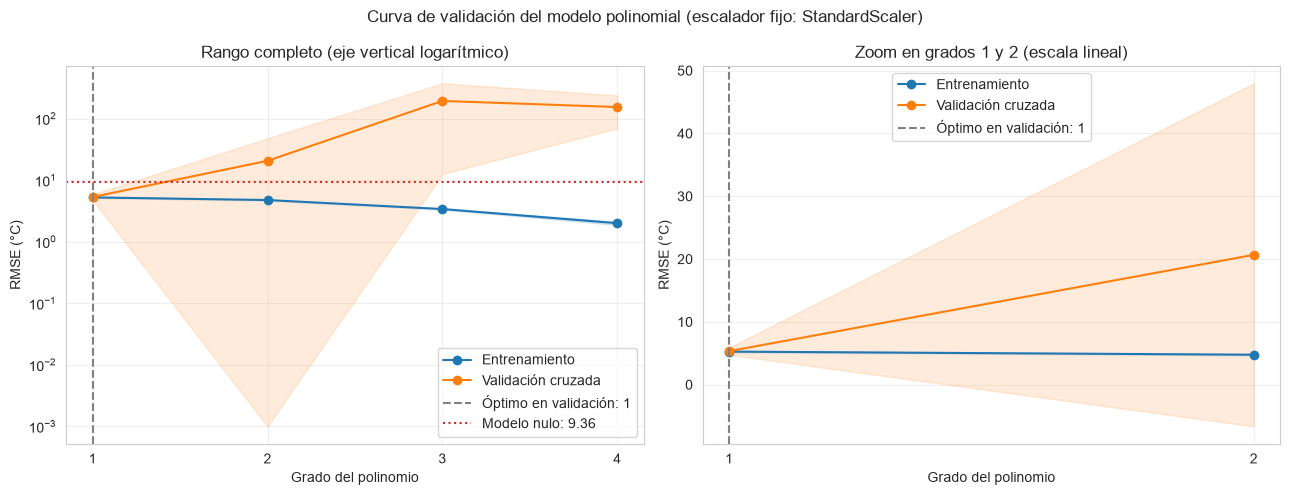

,Grado,Características,RMSE train,RMSE CV,Desv. RMSE CV,Brecha (CV - train)
0,1,33,5.2579,5.3373,0.5804,0.0794
1,2,153,4.7645,20.6643,27.3157,15.8998
2,3,833,3.4004,194.2349,181.6554,190.8345
3,4,3893,2.0025,154.3402,84.5140,152.3377


In [9]:
grados = [1, 2, 3, 4]

train_scores, val_scores = validation_curve(
    estimator=pipeline_poly,
    X=X_train,
    y=y_train,
    param_name="preprocesamiento__num__polynomial__degree",
    param_range=grados,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

# Se corrige el signo de la convención de maximización de scikit-learn
train_rmse, val_rmse = -train_scores, -val_scores
train_media, train_desv = train_rmse.mean(axis=1), train_rmse.std(axis=1)
val_media, val_desv = val_rmse.mean(axis=1), val_rmse.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

graficar_curva_validacion(
    np.array(grados), train_media, train_desv, val_media, val_desv,
    param_name="Grado del polinomio", metric_name="RMSE", ax=axes[0], log_y=True,
)
axes[0].set_xticks(grados)
axes[0].axhline(rmse_nulo, color="tab:red", ls=":", label=f"Modelo nulo: {rmse_nulo:.2f}")
axes[0].set_title("Rango completo (eje vertical logarítmico)")
axes[0].legend()

n = 2   # zoom sobre el cambio de régimen
graficar_curva_validacion(
    np.array(grados[:n]), train_media[:n], train_desv[:n], val_media[:n], val_desv[:n],
    param_name="Grado del polinomio", metric_name="RMSE", ax=axes[1],
)
axes[1].set_xticks(grados[:n])
axes[1].set_title("Zoom en grados 1 y 2 (escala lineal)")

fig.suptitle("Curva de validación del modelo polinomial (escalador fijo: StandardScaler)")
plt.tight_layout()
plt.show()

# --- Tabla numérica de apoyo ---
tabla_curva = pd.DataFrame({
    "Grado": grados,
    "Características": [f["Características"] for f in tabla_caracteristicas_poly],
    "RMSE train": train_media,
    "RMSE CV": val_media,
    "Desv. RMSE CV": val_desv,
    "Brecha (CV - train)": val_media - train_media,
})
display(tabla_curva.style.format({
    "RMSE train": "{:.4f}", "RMSE CV": "{:.4f}",
    "Desv. RMSE CV": "{:.4f}", "Brecha (CV - train)": "{:.4f}",
}))

### 3.1 Interpretación en términos de sesgo y varianza

La curva no tiene la forma de U de los ejemplos de texto, y eso es en sí mismo el resultado: **el
mínimo de validación está en el grado 1 y el sobreajuste aparece en el primer paso de complejidad, el
grado 2.** No hay un tramo inicial en el que añadir flexibilidad ayude.

Las dos curvas se comportan de forma opuesta. El error de **entrenamiento** desciende de forma monótona,
de 5.26 °C en grado 1 a 2.00 °C en grado 4: al agregar potencias y productos el modelo siempre puede
ajustar mejor los datos que ya vio, y con 3 893 parámetros para 1 860 observaciones puede prácticamente
memorizarlos. El error de **validación cruzada** hace lo contrario: 5.34 °C, 20.66 °C, 194.23 °C y
154.34 °C. La brecha entre ambas curvas pasa de 0.08 °C a más de 190 °C.

En el lenguaje del trade-off sesgo-varianza: el grado 1 es el punto de **sesgo relativamente alto pero
varianza baja**, y resulta ser el mejor compromiso disponible. Cada grado adicional compra una reducción
de sesgo pequeña —el error de entrenamiento baja unos 0.5 °C por grado— a cambio de un aumento de
varianza desproporcionado. La banda de ±1 desviación estándar lo hace visible: en el grado 1 mide
0.58 °C, mientras que en los grados 3 y 4 es del orden del propio promedio, es decir, el error cambia
por completo según qué pliegue se use para validar. Eso es varianza, por definición.

Vale la pena señalar hasta dónde llega el deterioro. A partir del grado 2 el modelo polinomial es
**peor que el modelo nulo** (9.36 °C), que no usa ninguna predictora y simplemente predice la media
histórica. Un modelo con 153 parámetros que predice peor que una constante es la ilustración más nítida
posible de que la complejidad, por sí sola, no aporta capacidad predictiva.

Sobre el tramo final de la curva conviene ser explícito para no sobreinterpretarlo: que el grado 4
aparezca por debajo del grado 3 no significa que el modelo empiece a recuperarse. Desde el grado 3 hay
833 y luego 3 893 columnas para 1 860 filas, el sistema de mínimos cuadrados es indeterminado y la
solución que devuelve el algoritmo depende de detalles numéricos. El orden relativo entre esos dos
puntos no es un hallazgo; lo que la curva sostiene es que después del grado 1 la generalización se
pierde y no vuelve.

Esto deja planteada la pregunta que trabajan las secciones 4 y 5: si el problema del modelo complejo es
varianza y no sesgo, entonces penalizar la magnitud de los coeficientes debería recuperar parte del
terreno perdido. La sección 4 mide cuánto margen hay para eso sobre la representación lineal, y la
sección 5 lo prueba directamente sobre la expansión polinomial.

---
## 4. Actividad 3. Modelos de regresión lineal regularizados
**Rúbrica: criterio 2, 15 %**

En esta sección se mide el efecto de la regularización sobre modelos lineales. A diferencia de la
sección 2, aquí **no** hay expansión polinomial: el objetivo es aislar el efecto de las penalizaciones
L2 y L1 sobre una misma representación de las variables.

Se construyen tres modelos comparables:

- Regresión lineal sin regularización, como referencia.
- **Ridge**, con penalización L2, que encoge los coeficientes de forma continua sin anularlos.
- **Lasso**, con penalización L1, que puede llevar coeficientes exactamente a cero y hace por tanto
  selección de variables.

Los tres comparten la misma representación, el mismo objeto `KFold` y las mismas métricas. Esto es
esencial: si el modelo sin penalizar usara un preprocesamiento distinto o pliegues distintos, la
diferencia observada no mediría el efecto de la regularización sino el de esos otros cambios.

**El escalamiento deja de ser opcional aquí.** La penalización suma los coeficientes (al cuadrado en
Ridge, en valor absoluto en Lasso), de modo que castiga por igual a todos sin saber en qué unidades está
cada variable. Si `presion_media` se mide en centenares de hPa y `viento_desv` en unidades, el
coeficiente de la presión será numéricamente pequeño solo por la escala de su variable, y la
penalización lo dejará casi intacto mientras aplasta a la otra. El escalamiento previo es lo que hace
que la penalización trate a todas las variables en igualdad de condiciones, y por eso va dentro del
pipeline y no antes de la partición.

### 4.1 Modelo lineal sin regularización

Se ajusta primero el modelo sin penalización, con exactamente el mismo preprocesamiento que usarán Ridge
y Lasso, para que la comparación posterior aísle el efecto de la regularización.

Aunque en este modelo el escalador es irrelevante para las predicciones —la regresión lineal sin
penalizar es invariante a transformaciones afines—, se mantiene el eje del escalador en la rejilla para
que las tres búsquedas sean estructuralmente idénticas. El resultado esperado, y que sirve como
verificación del montaje, es que las tres opciones produzcan el mismo RMSE.

In [10]:
# --- Rama numérica sin expansión polinomial: imputación -> escalado ---
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])


def construir_preprocesador():
    """Preprocesamiento común a los tres modelos de esta sección."""
    return ColumnTransformer(transformers=[
        ("num", transformador_numerico, variables_numericas),
        ("cat", transformador_categorico, variables_categoricas),
    ])


ESCALADORES = [StandardScaler(), MinMaxScaler(), RobustScaler()]

pipeline_lineal = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", LinearRegression()),
])

grid_lineal = GridSearchCV(
    estimator=pipeline_lineal,
    param_grid={"preprocesamiento__num__scaler": ESCALADORES},
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lineal.fit(X_train, y_train)

mejor_lineal = grid_lineal.best_estimator_
resultado_lineal = extraer_resultados(grid_lineal, "Regresión lineal")

print(f"Mejores hiperparámetros: {formatear_params(grid_lineal.best_params_)}")
print(f"RMSE CV: {resultado_lineal['RMSE medio CV']:.4f} ± {resultado_lineal['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_lineal['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_lineal['R² medio CV']:.4f}")

# Verificación del montaje: sin penalización el escalador no debe cambiar nada
rmse_por_escalador = pd.DataFrame({
    "Escalador": [type(s).__name__ for s in ESCALADORES],
    "RMSE CV": -pd.Series(grid_lineal.cv_results_["mean_test_RMSE"]),
})
print("\nEfecto del escalador sin penalización:")
print(rmse_por_escalador.to_string(index=False))
print("Los tres valores coinciden: la regresión lineal sin regularizar es invariante al escalado afín.")

Mejores hiperparámetros: scaler=RobustScaler
RMSE CV: 5.3373 ± 0.5804 °C
MAE CV:  3.7942 °C   R² CV: 0.6719

Efecto del escalador sin penalización:
     Escalador  RMSE CV
StandardScaler   5.3373
  MinMaxScaler   5.3373
  RobustScaler   5.3373
Los tres valores coinciden: la regresión lineal sin regularizar es invariante al escalado afín.


### 4.2 Regresión Ridge

Se añade la penalización L2 al mismo pipeline. El parámetro `alpha`, que controla la fuerza de la
penalización, entra en la búsqueda junto con el eje del escalador.

**Rango de `alpha`: 15 valores en escala logarítmica entre 10⁻⁴ y 10³.** La escala logarítmica es la
adecuada porque el efecto de `alpha` es multiplicativo: la diferencia entre 0.01 y 0.1 es del mismo
orden cualitativo que la que hay entre 10 y 100, mientras que una rejilla lineal gastaría casi todos sus
puntos en la zona de penalización fuerte. El rango extiende hacia abajo el de la práctica 6
(10⁻³ a 10³) para que el óptimo pueda quedar en el interior de la rejilla y no en su frontera: un
óptimo en el borde indicaría que el rango explorado fue insuficiente y que la búsqueda no está
concluida. El extremo superior, 10³, es suficientemente grande para que la penalización domine por
completo y el modelo tienda al nulo, lo que permite ver el régimen de subajuste.

In [11]:
ALPHAS = np.logspace(-4, 3, 15)
print(f"Rejilla de alpha ({len(ALPHAS)} valores): {np.array2string(ALPHAS, precision=4)}")

pipeline_ridge = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", Ridge()),
])

param_grid_ridge = {
    "modelo__alpha": ALPHAS,
    "preprocesamiento__num__scaler": ESCALADORES,
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_ridge.fit(X_train, y_train)

mejor_ridge = grid_ridge.best_estimator_
resultado_ridge = extraer_resultados(grid_ridge, "Ridge")

print(f"\nMejores hiperparámetros: {formatear_params(grid_ridge.best_params_)}")
print(f"RMSE CV: {resultado_ridge['RMSE medio CV']:.4f} ± {resultado_ridge['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_ridge['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_ridge['R² medio CV']:.4f}")

alpha_ridge = grid_ridge.best_params_["modelo__alpha"]
print(f"\nEl óptimo alpha = {alpha_ridge:g} queda en el interior de la rejilla "
      f"[{ALPHAS.min():g}, {ALPHAS.max():g}]: el rango explorado fue suficiente.")

Rejilla de alpha (15 valores): [1.0000e-04 3.1623e-04 1.0000e-03 3.1623e-03 1.0000e-02 3.1623e-02
 1.0000e-01 3.1623e-01 1.0000e+00 3.1623e+00 1.0000e+01 3.1623e+01
 1.0000e+02 3.1623e+02 1.0000e+03]



Mejores hiperparámetros: alpha=1, scaler=MinMaxScaler
RMSE CV: 5.3310 ± 0.5833 °C
MAE CV:  3.7923 °C   R² CV: 0.6727

El óptimo alpha = 1 queda en el interior de la rejilla [0.0001, 1000]: el rango explorado fue suficiente.


### 4.3 Regresión Lasso

Se repite el procedimiento con penalización L1 y la misma rejilla de `alpha`, para que Ridge y Lasso sean
comparables.

`Lasso` se resuelve por descenso por coordenadas, un método iterativo, mientras que Ridge tiene solución
cerrada. Con valores de `alpha` muy pequeños la convergencia es lenta, así que se eleva `max_iter` hasta
que no queden advertencias de convergencia: un modelo que no convergió no es un modelo peor, es un
modelo cuyos coeficientes no son los que la formulación define, y reportarlo sería reportar un número sin
significado.

In [12]:
pipeline_lasso = Pipeline(steps=[
    ("preprocesamiento", construir_preprocesador()),
    ("modelo", Lasso(max_iter=100_000)),
])

param_grid_lasso = {
    "modelo__alpha": ALPHAS,
    "preprocesamiento__num__scaler": ESCALADORES,
}

grid_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    cv=kfold,
    scoring=scoring,
    refit=REFIT_METRIC,
    return_train_score=True,
    n_jobs=-1,
)
grid_lasso.fit(X_train, y_train)

mejor_lasso = grid_lasso.best_estimator_
resultado_lasso = extraer_resultados(grid_lasso, "Lasso")

print(f"Mejores hiperparámetros: {formatear_params(grid_lasso.best_params_)}")
print(f"RMSE CV: {resultado_lasso['RMSE medio CV']:.4f} ± {resultado_lasso['Desv. RMSE']:.4f} °C")
print(f"MAE CV:  {resultado_lasso['MAE medio CV']:.4f} °C   "
      f"R² CV: {resultado_lasso['R² medio CV']:.4f}")

alpha_lasso = grid_lasso.best_params_["modelo__alpha"]
print(f"\nalpha óptimo = {alpha_lasso:g}. No se emitieron advertencias de convergencia "
      f"con max_iter = 100 000.")

Mejores hiperparámetros: alpha=0.001, scaler=MinMaxScaler
RMSE CV: 5.3338 ± 0.5821 °C
MAE CV:  3.7915 °C   R² CV: 0.6724

alpha óptimo = 0.001. No se emitieron advertencias de convergencia con max_iter = 100 000.


### 4.4 Efecto de la penalización sobre los coeficientes

Aquí hay una trampa de comparación que conviene desactivar antes de mirar cualquier número: **las
magnitudes de los coeficientes no son comparables entre modelos que ganaron con escaladores distintos.**
`MinMaxScaler` comprime cada variable al intervalo [0, 1], mientras que `StandardScaler` la deja con
desviación 1; como el rango típico de una variable estandarizada es varias veces mayor, los coeficientes
que acompañan a una representación MinMax son necesariamente más grandes para producir el mismo efecto
sobre la predicción. Comparar la norma del Ridge ajustado con MinMax contra la del modelo lineal
ajustado con Robust mediría la diferencia de escalado, no la de penalización.

Por eso el análisis de coeficientes **fija el escalador en `StandardScaler` para los tres modelos** y,
para cada uno, toma el `alpha` que resultó óptimo *condicionado a ese escalador*, recuperándolo de los
mismos `cv_results_` de las búsquedas anteriores. Así las tres representaciones son idénticas, cada
modelo mantiene su hiperparámetro elegido por validación cruzada, y las magnitudes sí se pueden comparar
entre sí.

Se examinan tres cosas: la magnitud y el signo de los coeficientes de los tres modelos sobre la misma
representación; cuántas y cuáles variables anula Lasso en su óptimo; y la **ruta de regularización**,
es decir, cómo evolucionan los coeficientes y el número de variables sobrevivientes a medida que crece
`alpha`. La ruta es lo que muestra la diferencia estructural entre L2 y L1, que en el óptimo puede no
ser visible.

In [13]:
# =====================================================================
# Mejor alpha condicionado a StandardScaler, para que las magnitudes
# de los coeficientes sean comparables entre los tres modelos
# =====================================================================

def mejor_alpha_con_escalador(search, nombre_escalador="StandardScaler"):
    """Recupera de cv_results_ el alpha óptimo restringido a un escalador."""
    res = pd.DataFrame(search.cv_results_)
    res["Escalador"] = res["param_preprocesamiento__num__scaler"].apply(lambda s: type(s).__name__)
    res = res[res["Escalador"] == nombre_escalador]
    fila = res.loc[res["mean_test_RMSE"].idxmax()]     # mean_test_RMSE viene negado
    return float(fila["param_modelo__alpha"]), -float(fila["mean_test_RMSE"])


alpha_ridge_std, rmse_ridge_std = mejor_alpha_con_escalador(grid_ridge)
alpha_lasso_std, rmse_lasso_std = mejor_alpha_con_escalador(grid_lasso)

print("Configuración común para comparar coeficientes (escalador = StandardScaler):")
print(f"  Lineal                   RMSE CV = {-grid_lineal.cv_results_['mean_test_RMSE'][0]:.4f} °C")
print(f"  Ridge  alpha={alpha_ridge_std:<8g} RMSE CV = {rmse_ridge_std:.4f} °C")
print(f"  Lasso  alpha={alpha_lasso_std:<8g} RMSE CV = {rmse_lasso_std:.4f} °C")

modelos_coef = {
    "Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=alpha_ridge_std),
    "Lasso": Lasso(alpha=alpha_lasso_std, max_iter=100_000),
}

coeficientes = {}
for nombre, estimador in modelos_coef.items():
    pipe = Pipeline(steps=[
        ("preprocesamiento", construir_preprocesador()),
        ("modelo", estimador),
    ]).set_params(preprocesamiento__num__scaler=StandardScaler())
    pipe.fit(X_train, y_train)
    tabla_coef, _ = extraer_coeficientes(pipe)
    coeficientes[nombre] = tabla_coef.set_index("Característica")["Coeficiente"]

tabla_comparacion_coef = pd.DataFrame(coeficientes)
tabla_comparacion_coef = tabla_comparacion_coef.reindex(
    tabla_comparacion_coef["Lineal"].abs().sort_values(ascending=False).index
)

resumen_magnitud = pd.DataFrame({
    "Modelo": list(coeficientes),
    "Coefs. totales": [len(s) for s in coeficientes.values()],
    "Coefs. no nulos": [int((s.abs() > TOL_CERO).sum()) for s in coeficientes.values()],
    "Mayor |coef|": [s.abs().max() for s in coeficientes.values()],
    "Norma L1 (Σ|coef|)": [s.abs().sum() for s in coeficientes.values()],
    "Norma L2": [np.sqrt((s ** 2).sum()) for s in coeficientes.values()],
})

print("\nMagnitud de los coeficientes sobre la misma representación:")
display(resumen_magnitud.style.format({
    "Mayor |coef|": "{:.4f}", "Norma L1 (Σ|coef|)": "{:.4f}", "Norma L2": "{:.4f}",
}))

print("Doce coeficientes de mayor magnitud (en °C por unidad estandarizada):")
display(tabla_comparacion_coef.head(12).style.format("{:.4f}"))

Configuración común para comparar coeficientes (escalador = StandardScaler):
  Lineal                   RMSE CV = 5.3373 °C
  Ridge  alpha=1        RMSE CV = 5.3366 °C
  Lasso  alpha=0.001    RMSE CV = 5.3369 °C

Magnitud de los coeficientes sobre la misma representación:


,Modelo,Coefs. totales,Coefs. no nulos,Mayor |coef|,Norma L1 (Σ|coef|),Norma L2
0,Lineal,33,33,10.5924,93.0118,24.5202
1,Ridge,33,33,10.3389,90.0990,23.9909
2,Lasso,33,33,10.5478,91.0597,24.2831


Doce coeficientes de mayor magnitud (en °C por unidad estandarizada):


,Lineal,Ridge,Lasso
Característica,,,
mes_calendario_enero,-10.5924,-10.3389,-10.5478
mes_calendario_febrero,-10.3985,-10.1681,-10.3623
mes_calendario_diciembre,-9.5958,-9.3490,-9.5513
mes_calendario_julio,8.5052,8.5344,8.5047
mes_calendario_agosto,7.3430,7.3844,7.3396
mes_calendario_junio,6.0981,6.1461,6.0923
mes_calendario_marzo,-6.0419,-5.8870,-6.0142
sector_viento_NO,-4.3159,-3.9313,-4.0343
mes_calendario_noviembre,-4.1200,-3.9264,-4.0778


In [14]:
# =====================================================================
# Variables que Lasso lleva a cero
# =====================================================================

# (a) En la representación común de 4.4, que permite comparar magnitudes
serie_lasso = coeficientes["Lasso"]
anuladas_std = serie_lasso[serie_lasso.abs() <= TOL_CERO].index.tolist()
sobrevivientes = serie_lasso[serie_lasso.abs() > TOL_CERO]

print(f"Lasso con StandardScaler y alpha = {alpha_lasso_std:g}")
print(f"  Características totales: {len(serie_lasso)}")
print(f"  Conservadas:             {len(sobrevivientes)}")
print(f"  Anuladas:                {len(anuladas_std)} -> "
      f"{anuladas_std if anuladas_std else 'ninguna'}")

# (b) En la configuración que ganó la búsqueda completa de la sección 4.3
coef_mejor_lasso, _ = extraer_coeficientes(mejor_lasso)
anuladas_mejor = coef_mejor_lasso.loc[
    coef_mejor_lasso["Magnitud"] <= TOL_CERO, "Característica"].tolist()

print(f"\nLasso en su configuración ganadora ({formatear_params(grid_lasso.best_params_)})")
print(f"  Conservadas: {len(coef_mejor_lasso) - len(anuladas_mejor)}")
print(f"  Anuladas:    {len(anuladas_mejor)} -> "
      f"{anuladas_mejor if anuladas_mejor else 'ninguna'}")

if anuladas_mejor:
    print("\nCoeficiente que esas variables tenían en el modelo sin regularizar:")
    print(coeficientes["Lineal"].reindex(anuladas_mejor)
          .to_frame("Coeficiente lineal").round(4).to_string())

print("\nDiez características de mayor magnitud conservadas por Lasso (StandardScaler):")
display(sobrevivientes.abs().sort_values(ascending=False).head(10).to_frame("Magnitud")
        .join(sobrevivientes.to_frame("Coeficiente")).style.format("{:.4f}"))

Lasso con StandardScaler y alpha = 0.001
  Características totales: 33
  Conservadas:             33
  Anuladas:                0 -> ninguna

Lasso en su configuración ganadora (alpha=0.001, scaler=MinMaxScaler)
  Conservadas: 31
  Anuladas:    2 -> ['presion_rango', 'humedad_rango']

Coeficiente que esas variables tenían en el modelo sin regularizar:
                Coeficiente lineal
Característica                    
presion_rango               0.0327
humedad_rango              -0.0069

Diez características de mayor magnitud conservadas por Lasso (StandardScaler):


,Magnitud,Coeficiente
Característica,,
mes_calendario_enero,10.5478,-10.5478
mes_calendario_febrero,10.3623,-10.3623
mes_calendario_diciembre,9.5513,-9.5513
mes_calendario_julio,8.5047,8.5047
mes_calendario_agosto,7.3396,7.3396
mes_calendario_junio,6.0923,6.0923
mes_calendario_marzo,6.0142,-6.0142
mes_calendario_noviembre,4.0778,-4.0778
sector_viento_NO,4.0343,-4.0343


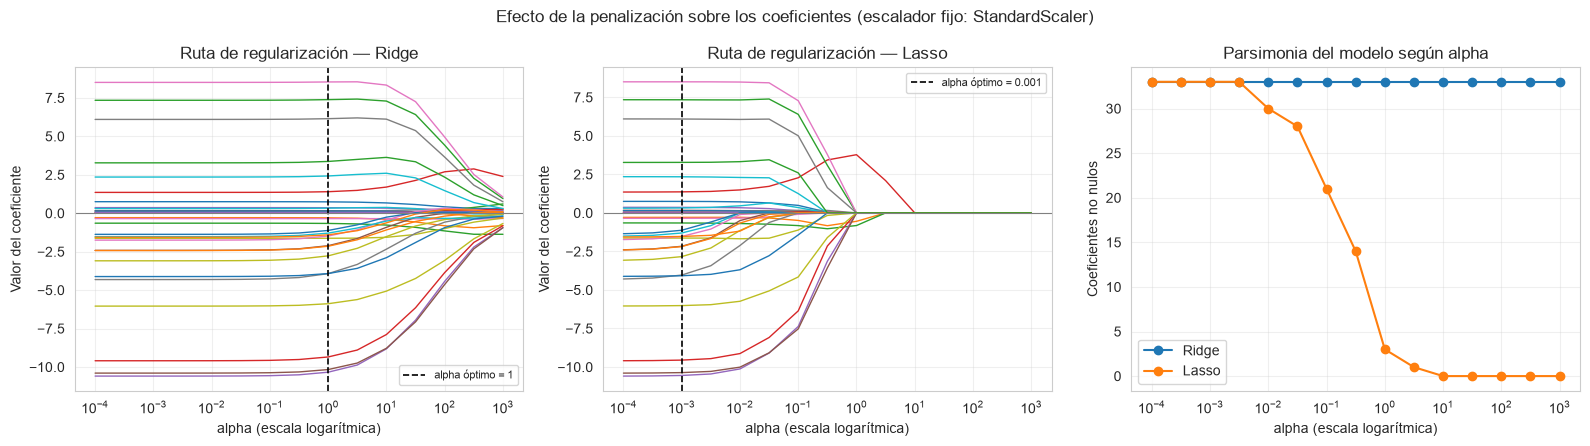

Error y parsimonia en función de alpha (escalador fijo: StandardScaler).
Referencia: el modelo nulo obtiene RMSE = 9.3596 °C.


,alpha,Ridge · RMSE CV,Ridge · coefs. no nulos,Lasso · RMSE CV,Lasso · coefs. no nulos,Lasso · costo vs óptimo (°C)
0,0.0001,5.3373,33,5.3372,33,+0.0003
1,0.0003162,5.3373,33,5.3371,33,+0.0002
2,0.001,5.3373,33,5.3369,33,+0.0000
3,0.003162,5.3373,33,5.3378,33,+0.0008
4,0.01,5.3372,33,5.3396,30,+0.0027
5,0.03162,5.3372,33,5.3605,28,+0.0236
6,0.1,5.3371,33,5.5105,21,+0.1736
7,0.3162,5.3369,33,6.4862,14,+1.1493
8,1,5.3366,33,7.6350,3,+2.2980
9,3.162,5.3391,33,8.3509,1,+3.0139


In [15]:
# =====================================================================
# Ruta de regularización: coeficientes y parsimonia en función de alpha
# =====================================================================

rutas = {}
for nombre, constructor in [("Ridge", lambda a: Ridge(alpha=a)),
                            ("Lasso", lambda a: Lasso(alpha=a, max_iter=100_000))]:
    matriz = []
    for a in ALPHAS:
        pipe = Pipeline(steps=[
            ("preprocesamiento", construir_preprocesador()),
            ("modelo", constructor(a)),
        ]).set_params(preprocesamiento__num__scaler=StandardScaler())
        pipe.fit(X_train, y_train)
        matriz.append(pipe.named_steps["modelo"].coef_)
    rutas[nombre] = np.array(matriz)

nombres_caracteristicas = list(coeficientes["Lineal"].index)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, nombre, alpha_opt in [(axes[0], "Ridge", alpha_ridge_std),
                              (axes[1], "Lasso", alpha_lasso_std)]:
    for j in range(rutas[nombre].shape[1]):
        ax.plot(ALPHAS, rutas[nombre][:, j], lw=1)
    ax.axvline(alpha_opt, color="k", ls="--", lw=1.2,
               label=f"alpha óptimo = {alpha_opt:g}")
    ax.axhline(0, color="gray", lw=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("alpha (escala logarítmica)")
    ax.set_ylabel("Valor del coeficiente")
    ax.set_title(f"Ruta de regularización — {nombre}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

no_nulos = {n: (np.abs(m) > TOL_CERO).sum(axis=1) for n, m in rutas.items()}
for nombre, color in [("Ridge", "tab:blue"), ("Lasso", "tab:orange")]:
    axes[2].plot(ALPHAS, no_nulos[nombre], "o-", label=nombre, color=color)
axes[2].set_xscale("log")
axes[2].set_xlabel("alpha (escala logarítmica)")
axes[2].set_ylabel("Coeficientes no nulos")
axes[2].set_title("Parsimonia del modelo según alpha")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Efecto de la penalización sobre los coeficientes (escalador fijo: StandardScaler)")
plt.tight_layout()
plt.show()

# --- Error y parsimonia en función de alpha, para las dos penalizaciones ---

def perfil_alpha(search, nombre_escalador="StandardScaler"):
    """RMSE de validación cruzada por valor de alpha, restringido a un escalador."""
    res = pd.DataFrame(search.cv_results_)
    res["Escalador"] = res["param_preprocesamiento__num__scaler"].apply(
        lambda s: type(s).__name__)
    res = res[res["Escalador"] == nombre_escalador].copy()
    res["alpha"] = res["param_modelo__alpha"].astype(float)
    res = res.sort_values("alpha")
    return -res["mean_test_RMSE"].values


tabla_parsimonia = pd.DataFrame({
    "alpha": ALPHAS,
    "Ridge · RMSE CV": perfil_alpha(grid_ridge),
    "Ridge · coefs. no nulos": no_nulos["Ridge"],
    "Lasso · RMSE CV": perfil_alpha(grid_lasso),
    "Lasso · coefs. no nulos": no_nulos["Lasso"],
})
tabla_parsimonia["Lasso · costo vs óptimo (°C)"] = (
    tabla_parsimonia["Lasso · RMSE CV"] - tabla_parsimonia["Lasso · RMSE CV"].min())

print("Error y parsimonia en función de alpha (escalador fijo: StandardScaler).")
print(f"Referencia: el modelo nulo obtiene RMSE = {rmse_nulo:.4f} °C.")
display(tabla_parsimonia.style.format({
    "alpha": "{:.4g}", "Ridge · RMSE CV": "{:.4f}", "Lasso · RMSE CV": "{:.4f}",
    "Lasso · costo vs óptimo (°C)": "{:+.4f}",
}))

### 4.5 Comparación entre el modelo sin regularización, Ridge y Lasso

Se consolidan los tres modelos en una tabla construida con el mismo esquema de validación cruzada. Cada
fila usa los hiperparámetros que la búsqueda eligió para ese modelo, que es la comparación correcta
desde el punto de vista de selección de modelos: se compara lo mejor que cada familia puede dar.

Además del promedio se reporta la desviación estándar entre pliegues, la brecha respecto al error de
entrenamiento y el número de coeficientes no nulos, que es la medida de complejidad efectiva relevante
cuando hay penalización L1.

,Modelo,Mejores hiperparámetros,RMSE medio CV,Desv. RMSE,MAE medio CV,R² medio CV,RMSE train,Brecha (CV - train),Coefs. no nulos
0,Regresión lineal,scaler=RobustScaler,5.3373,0.5804,3.7942,0.6719,5.2579,0.0794,33
1,Ridge,"alpha=1, scaler=MinMaxScaler",5.3310,0.5833,3.7923,0.6727,5.2603,0.0707,33
2,Lasso,"alpha=0.001, scaler=MinMaxScaler",5.3338,0.5821,3.7915,0.6724,5.2584,0.0753,31


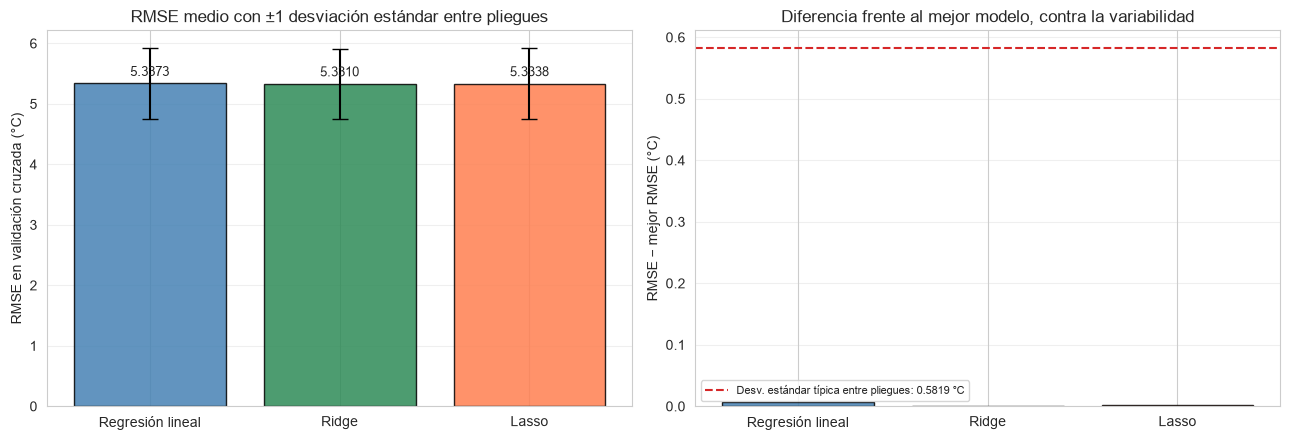

Rango de RMSE entre los tres modelos: 0.0063 °C
Desviación estándar típica entre pliegues: 0.5819 °C


In [16]:
tabla_regularizacion = pd.DataFrame([resultado_lineal, resultado_ridge, resultado_lasso])
tabla_regularizacion["Brecha (CV - train)"] = (
    tabla_regularizacion["RMSE medio CV"] - tabla_regularizacion["RMSE train"])

coefs_no_nulos = []
for pipe in [mejor_lineal, mejor_ridge, mejor_lasso]:
    tabla_coef, _ = extraer_coeficientes(pipe)
    coefs_no_nulos.append(int((tabla_coef["Magnitud"] > TOL_CERO).sum()))
tabla_regularizacion["Coefs. no nulos"] = coefs_no_nulos

columnas = ["Modelo", "Mejores hiperparámetros", "RMSE medio CV", "Desv. RMSE",
            "MAE medio CV", "R² medio CV", "RMSE train", "Brecha (CV - train)",
            "Coefs. no nulos"]

display(tabla_regularizacion[columnas].style.format({
    "RMSE medio CV": "{:.4f}", "Desv. RMSE": "{:.4f}", "MAE medio CV": "{:.4f}",
    "R² medio CV": "{:.4f}", "RMSE train": "{:.4f}", "Brecha (CV - train)": "{:.4f}",
}).highlight_min(subset=["RMSE medio CV"], color="lightgreen"))

# --- Gráfico: la diferencia entre modelos frente a la variabilidad entre pliegues ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

modelos_reg = tabla_regularizacion["Modelo"]
rmse_vals = tabla_regularizacion["RMSE medio CV"]
rmse_desv = tabla_regularizacion["Desv. RMSE"]

barras = axes[0].bar(modelos_reg, rmse_vals, yerr=rmse_desv, capsize=6,
                     color=["steelblue", "seagreen", "coral"], edgecolor="k", alpha=0.85)
axes[0].set_ylabel("RMSE en validación cruzada (°C)")
axes[0].set_title("RMSE medio con ±1 desviación estándar entre pliegues")
axes[0].grid(axis="y", alpha=0.3)
for barra, valor in zip(barras, rmse_vals):
    axes[0].text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.08,
                 f"{valor:.4f}", ha="center", va="bottom", fontsize=9)

# Zoom: la escala de las diferencias reales entre los tres modelos
base = rmse_vals.min()
axes[1].bar(modelos_reg, rmse_vals - base,
            color=["steelblue", "seagreen", "coral"], edgecolor="k", alpha=0.85)
axes[1].axhline(rmse_desv.mean(), color="tab:red", ls="--",
                label=f"Desv. estándar típica entre pliegues: {rmse_desv.mean():.4f} °C")
axes[1].set_ylabel("RMSE − mejor RMSE (°C)")
axes[1].set_title("Diferencia frente al mejor modelo, contra la variabilidad")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Rango de RMSE entre los tres modelos: {rmse_vals.max() - rmse_vals.min():.4f} °C")
print(f"Desviación estándar típica entre pliegues: {rmse_desv.mean():.4f} °C")

### 4.6 Lectura de la comparación

**Los tres modelos son indistinguibles en desempeño.** El RMSE en validación cruzada va de 5.331 °C
(Ridge) a 5.337 °C (lineal), un rango de unas seis milésimas de grado, frente a una desviación estándar
entre pliegues de 0.58 °C. La diferencia entre los modelos es unas cien veces menor que la variabilidad
de la propia estimación, así que no hay base para afirmar que uno generalice mejor que otro: el panel
derecho de la figura contrasta precisamente esas dos escalas. MAE y R² ordenan los modelos igual y con
la misma magnitud de diferencia, de modo que la conclusión no depende de la métrica.

**Por qué la regularización no aporta aquí, y eso es un resultado, no un fracaso.** La regularización
compra reducción de varianza a cambio de sesgo, y solo es rentable cuando hay varianza que reducir. En
esta representación hay 33 coeficientes para 1 860 observaciones de entrenamiento, unas 56
observaciones por parámetro, y la brecha entre el error de entrenamiento (5.26 °C) y el de validación
(5.34 °C) es de apenas 0.08 °C. Un modelo que generaliza casi tan bien como se ajusta no está
sobreajustando, y por tanto no tiene nada que ganar con una penalización. Es el contraste exacto de la
sección 3: el modelo polinomial de grado 2, con 153 parámetros, sí tenía una brecha enorme, y es ahí
donde la regularización tiene algo que hacer. La sección 5 lo comprueba directamente.

Que los valores óptimos de `alpha` sean pequeños (1 para Ridge, 0.001 para Lasso) confirma lo mismo desde
otro ángulo: la validación cruzada está pidiendo *casi nada* de penalización, es decir, está
recomendando quedarse muy cerca del modelo sin regularizar. Y la tabla de la sección 4.4 muestra que más
allá de ese óptimo el error solo empeora, de forma monótona en ambos modelos: Ridge sube de 5.337 °C a
7.284 °C al llegar a `alpha` = 1 000, y Lasso se estanca en 9.344 °C desde `alpha` = 10, que es el error
de un modelo que ya anuló los 33 coeficientes y solo conserva el intercepto, prácticamente el mismo
9.360 °C del modelo nulo. Ese es el régimen de subajuste por penalización excesiva, el espejo del
sobreajuste de la sección 3.

**Efecto sobre la magnitud de los coeficientes.** Sobre la representación común con `StandardScaler`, la
norma L2 de los coeficientes baja de 24.52 en el modelo sin penalizar a 23.99 con Ridge y 24.28 con
Lasso: una contracción de apenas un 2 %, coherente con lo pequeño de los `alpha` elegidos. El encogimiento
no es uniforme, y ahí sí se ve el mecanismo. Los coeficientes que más se reducen son los del bloque de
`sector_viento`: `sector_viento_NO` pasa de −4.316 a −3.931, `sector_viento_O` de −3.096 a −2.774 y
`sector_viento_SO` de −2.427 a −2.148, entre un 9 % y un 12 % cada uno. Las indicadoras de mes, en
cambio, apenas se mueven y algunas incluso crecen (`mes_calendario_julio` va de 8.505 a 8.534).

La explicación más plausible de ese contraste es la redundancia. `sector_viento` es una discretización en
ocho octantes de la misma dirección del viento que `viento_norte` y `viento_este` ya codifican de forma
continua, de modo que el bloque de indicadoras de sector vive casi dentro del subespacio que esas dos
variables generan y los datos lo determinan débilmente: hay muchas combinaciones de esos coeficientes que
ajustan los datos casi igual de bien. Las indicadoras de mes, en cambio, aportan el ciclo estacional, que
ninguna otra variable del conjunto reproduce, y están además repartidas de forma equilibrada (entre 135 y
163 observaciones por mes en entrenamiento). La penalización encoge preferentemente las direcciones que
la evidencia no fija, que es exactamente lo que se espera de ella, y de paso explica por qué las dos
variables que Lasso sí llega a anular son variables de rango con coeficientes ya minúsculos.

Las rutas de regularización hacen visible la diferencia estructural entre las dos penalizaciones, que en
el óptimo queda oculta. En **Ridge** los 33 coeficientes se contraen de forma continua hacia cero pero
ninguno llega a anularse en todo el rango explorado: el modelo conserva siempre las 33 variables. En
**Lasso** el número de coeficientes no nulos cae por escalones —33, 30, 28, 21, 14, 3, 1 y finalmente
0— a medida que `alpha` crece. Esa es la selección automática de características: L1 no encoge, elimina.

**Qué elimina Lasso y qué significa.** En su óptimo (`alpha` = 0.001 con `StandardScaler`) Lasso no
anula ninguna variable, y con el escalador que gana globalmente anula solo dos: `presion_rango` y
`humedad_rango`, precisamente las dos de coeficiente más pequeño en el modelo sin penalizar (0.033 y
−0.007 °C por unidad estandarizada). La lectura honesta es que **en este conjunto de variables no hay
redundancia relevante que eliminar**: la ingeniería de características del Laboratorio 1 ya había
sustituido los pares mínimo/máximo por rangos y descartado las variables duplicadas, así que Lasso llega
a un conjunto sobre el que queda poco por podar.

Aun así, la tabla de parsimonia muestra que existe un compromiso aprovechable. Con `alpha` = 0.0316
Lasso conserva 28 de las 33 características a un costo de 0.023 °C de RMSE, y con `alpha` = 0.1 conserva
21 características por 0.174 °C. Para AlpesPlanck esa es una decisión de ingeniería más que de
estadística: si mantener un sensor o una variable derivada tiene costo operativo, sacrificar dos
centésimas de grado por prescindir de cinco variables puede ser un buen negocio, y la tabla cuantifica
el precio exacto de cada nivel de simplificación.

**Sobre la elección del escalador.** Ridge y Lasso eligen `MinMaxScaler` y el modelo lineal
`RobustScaler`, pero las diferencias son de milésimas de grado y caen dentro del ruido, así que la
elección del escalador no está realmente determinada por los datos. Conviene no leerla como un hallazgo.
Lo que sí importa —y se verificó explícitamente en 4.1— es que sin penalización el escalador no cambia
nada, mientras que con penalización sí interactúa con `alpha`: el `alpha` óptimo depende del escalador,
porque ambas cosas actúan sobre la misma magnitud. Esa es la razón de fondo por la que el análisis de
coeficientes de 4.4 tuvo que fijar el escalador antes de comparar magnitudes.

**Qué se lleva la sección 5.** Como Ridge y Lasso son equivalentes en desempeño sobre esta
representación, la evidencia de esta sección no basta por sí sola para escoger entre L1 y L2 para el
modelo polinomial regularizado; la decisión debe argumentarse con el criterio que resulte pertinente
allí (número de términos de interacción, interpretabilidad o costo de la búsqueda) y verificarse con
validación cruzada.

## 5. Actividad 4. Regresión polinomial regularizada

En esta actividad se combinarán los dos mecanismos de control de complejidad estudiados anteriormente:

- La generación de características polinomiales.
- La regularización de los coeficientes.

Se construirá un pipeline que combine `PolynomialFeatures` con un estimador regularizado, utilizando Ridge o Lasso según la evidencia obtenida en la sección anterior.

La búsqueda mediante `GridSearchCV` explorará simultáneamente:

- El grado del polinomio.
- El parámetro de penalización.
- La estrategia de escalamiento.

El modelo será evaluado mediante RMSE, MAE y R² utilizando el mismo esquema de validación cruzada empleado en las demás actividades.

El análisis se concentrará en determinar si la regularización permite controlar el sobreajuste cuando aumenta la complejidad del modelo.

No se asumirá previamente que el modelo regularizado permitirá utilizar un grado mayor. Esta conclusión se establecerá únicamente a partir de los resultados obtenidos.

In [17]:
# TODO 5
# - Construir el pipeline que combina expansión polinomial y estimador regularizado.
# - Definir la rejilla de tres ejes y estimar el número de ajustes.
# - Ejecutar la búsqueda (en rejilla o aleatoria, justificando la elección).
# - Reportar mejores hiperparámetros y las tres métricas con media y desviación.
# - Comparar el grado óptimo obtenido aquí con el de la sección 2.

## 6. Actividad 5. Comparación y selección del mejor modelo

Una vez terminadas las búsquedas de hiperparámetros, se consolidarán los resultados de validación cruzada de los modelos construidos.

La comparación incluirá:

| Modelo | Mejores hiperparámetros | RMSE medio CV | Desv. RMSE | MAE medio CV | R² medio CV | Complejidad |
|:---|:---|---:|---:|---:|---:|:---|
| Regresión lineal | | | | | | |
| Regresión polinomial | | | | | | |
| Ridge | | | | | | |
| Lasso | | | | | | |
| Polinomial regularizado | | | | | | |

La elección del modelo final no dependerá únicamente de cuál obtenga el menor error promedio.

Tal como establece el enunciado, se tendrán en cuenta tres aspectos:

1. Desempeño promedio en validación cruzada.
2. Estabilidad, representada mediante la desviación estándar entre pliegues.
3. Complejidad del modelo.

La selección se realizará antes de utilizar el conjunto de test.

Al finalizar esta sección se dejará explícitamente identificado el modelo seleccionado y sus mejores hiperparámetros.

In [18]:
# TODO 6
# - Construir el DataFrame comparativo con una fila por modelo.
# - Ordenar por la métrica principal y mostrarlo.
# - Opcional: gráfico de barras con la media y la barra de error de la desviación.
# - Seleccionar el modelo final y guardarlo en una variable.

### 6.1 Argumentación escrita de la selección

**Qué escribir.** Un párrafo que nombre el modelo elegido, liste sus hiperparámetros ganadores y explique
la elección en las tres dimensiones anteriores. Si el modelo elegido no es el de mejor media, la
explicación de por qué se prefirió la estabilidad es exactamente lo que la rúbrica quiere ver.

## 7. Evaluación final e intervalos de confianza

Una vez terminada la selección de modelos y congeladas todas las decisiones de modelado, se utilizará el conjunto de test.

El conjunto de test no se utilizará para modificar grados, parámetros de regularización, estrategias de escalamiento ni ninguna otra decisión tomada anteriormente.

### 7.1 Evaluación final sobre el conjunto de test

Los modelos finales obtenidos en las actividades anteriores se evaluarán sobre el conjunto de test utilizando:

- RMSE.
- MAE.
- R².

Esta evaluación se realizará únicamente después de haber terminado la selección de hiperparámetros mediante validación cruzada.

Los resultados se consolidarán en una tabla:

| Modelo | RMSE test | MAE test | R² test |
|:---|---:|---:|---:|
| Regresión lineal | | | |
| Regresión polinomial | | | |
| Ridge | | | |
| Lasso | | | |
| Polinomial regularizado | | | |

Esta tabla permitirá responder posteriormente si el modelo que presentó el mejor comportamiento promedio en validación cruzada coincide con el modelo que obtiene el mejor resultado en el conjunto de test.

Los resultados de test no se utilizarán para reajustar los modelos.

In [19]:
# TODO 7.1
# - Verificar que los modelos finales estén ajustados sobre todo el entrenamiento.
# - Predecir sobre test y calcular RMSE, MAE y R2 puntuales para cada modelo.
# - Consolidar la tabla de la sección 7.1 ordenada por RMSE de test.
# - Nota: en esta versión de scikit-learn `mean_squared_error(..., squared=False)`
#   ya no existe; usar np.sqrt(mean_squared_error(...)) como en la práctica 5.

### 7.2 Intervalos de confianza mediante bootstrapping

El procedimiento de bootstrapping se aplicará al modelo seleccionado previamente en la sección 6.

Se utilizará el conjunto de test y se realizarán al menos 500 remuestreos con reemplazo.

En cada remuestreo se calcularán nuevamente las métricas de desempeño utilizando las observaciones reales y sus predicciones correspondientes.

Se estimarán intervalos de confianza del 95 % para:

- RMSE.
- MAE.
- R².

Los intervalos se obtendrán utilizando los percentiles 2.5 y 97.5 de las distribuciones generadas mediante bootstrap.

También se visualizarán las distribuciones de las métricas remuestreadas y de los errores de predicción.

El objetivo de esta etapa es cuantificar la incertidumbre asociada al desempeño del modelo y analizar su estabilidad.

In [20]:
# TODO 7.2
# - Implementar el bucle de bootstrapping con al menos 500 remuestreos sobre índices
#   del conjunto de test, usando RANDOM_STATE para que sea reproducible.
# - Calcular percentiles 2.5 y 97.5 de RMSE, MAE y R2.
# - Graficar los histogramas de las métricas remuestreadas con el intervalo marcado.
# - Graficar la distribución de residuales y calcular el cociente RMSE/MAE.

## 8. Análisis de resultados

Las siguientes preguntas se responderán utilizando exclusivamente la evidencia obtenida en las secciones anteriores.

Cada respuesta deberá apoyarse en las métricas, tablas o gráficas producidas durante el laboratorio.

### 8.1 Análisis cuantitativo

#### a. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

**Evidencia:** tabla de la sección 7.1.

**Respuesta:**

---

#### b. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

**Evidencia:** tablas de las secciones 6 y 7.1.

**Respuesta:**

---

#### c. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado?

**Evidencia:** promedio y desviación estándar de las métricas de validación cruzada.

**Respuesta:**

---

#### d. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

**Evidencia:** curva de validación de la sección 3.

**Respuesta:**

---

#### e. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

**Evidencia:** comparación entre regresión lineal, Ridge y Lasso.

**Respuesta:**

---

#### f. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

**Evidencia:** resultados de la sección 7.2.

**Respuesta:**

### 8.2 Análisis cualitativo

#### a. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

**Evidencia:** coeficientes del mejor modelo Lasso.

**Respuesta:**

---

#### b. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?

**Evidencia:** coeficientes y representación utilizada por el modelo final.

**Respuesta:**

---

#### c. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

**Evidencia:** resultados comparativos de desempeño y complejidad.

**Respuesta:**

---

#### d. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?

**Evidencia:** resultados del modelo final y variables relevantes.

**Respuesta:**

---

#### e. ¿Mayor precisión implica necesariamente mayor valor para la organización?

**Respuesta:**

---

#### f. ¿Un modelo más complejo necesariamente genera mayor valor empresarial?

Considerar interpretabilidad, estabilidad y costo de implementación.

**Respuesta:**

### 8.3 Reflexión conceptual

#### a. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

**Evidencia:** curvas de validación, resultados de regularización y bootstrap.

**Respuesta:**

---

#### b. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

**Respuesta:**

---

#### c. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos?

**Respuesta:**

---
## 9. Actividad 7. Video explicativo
**Rúbrica: criterio 7, 5 %. Máximo 3 minutos.**

**Audiencia.** El ingeniero de machine learning que lidera el grupo de AlpesPlanck. Es una audiencia
técnica: no hay que explicar qué es la validación cruzada, hay que explicar qué decidiste y por qué.

**Estructura sugerida para tres minutos.**

1. Punto de partida y objetivo, con el resultado del Laboratorio 1 como referencia (unos 20 segundos).
2. Los modelos comparados y el criterio de comparación (40 segundos).
3. El hallazgo sobre complejidad y sobreajuste, mostrando la curva de validación (40 segundos).
4. El modelo seleccionado, sus hiperparámetros y por qué se eligió, incluyendo la estabilidad (40 segundos).
5. El intervalo de confianza y qué significa para el uso de la predicción (30 segundos).
6. Limitaciones y siguiente paso recomendado (10 segundos).

**Error frecuente.** Gastar dos minutos describiendo el código. El líder técnico quiere las decisiones y
la evidencia, no un recorrido por las celdas.

---
## 10. Uso de herramientas de IA generativa
**Rúbrica: criterio 8, 5 %. La sección debe llevar exactamente este título.**

Según las reglas del curso, esta sección debe contener cuatro componentes. Si falta cualquiera de ellos,
el criterio se pierde completo, que es una forma barata de perder 5 %.

**1. Declaración del uso.** Nombre de la herramienta y tipo de uso: ayuda conceptual, generación inicial
de código, explicación teórica, depuración, redacción, u otro.

**2. Prompts utilizados.** De forma textual o resumida. No hacen falta las interacciones menores, pero sí
las que influyeron directamente en el resultado entregado.

**3. Análisis crítico del resultado.** Hay que responder al menos dos de estas preguntas:

- ¿Qué partes del contenido generado fueron correctas y útiles?
- ¿Qué errores, imprecisiones o limitaciones se identificaron?
- ¿Qué decisiones técnicas fueron modificadas respecto a la respuesta de la IA y por qué?
- ¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?

**4. Aportes propios.** Qué fue desarrollado, modificado o decidido por ustedes; qué ajustes se hicieron
sobre el código o la explicación original; y qué aprendizajes se obtuvieron del proceso.

**Nota del esqueleto.** Si usaste este esqueleto, es un uso de IA generativa y debe declararse. El
análisis crítico correspondiente puede apoyarse en las decisiones que el esqueleto dejó abiertas de forma
deliberada y que ustedes tuvieron que resolver, por ejemplo el tipo de partición frente a la estructura
temporal de los datos, o la elección entre Ridge y Lasso para el modelo polinomial regularizado.

> **Insumo para la sección 10 (eliminar esta nota una vez redactada la sección).**
> Datos que solo conoce quien desarrolló las secciones 1 a 4, y que hacen falta para poder declarar el
> uso de IAG de forma completa:
>
> - **Herramienta y tipo de uso.** Claude (Anthropic), usado para: generar el esqueleto del notebook;
>   producir una primera versión del código de las secciones 1 a 4; y revisar la redacción de las
>   justificaciones escritas.
> - **Errores e imprecisiones detectados en lo generado**, que hubo que corregir a mano: la primera
>   versión no descartaba las filas sin variable objetivo, lo que hacía fallar todas las búsquedas de
>   hiperparámetros; usaba `PolynomialFeatures` con el término constante activado, que duplica el
>   intercepto y queda penalizado en los modelos regularizados; comparaba magnitudes de coeficientes
>   entre modelos ajustados con escaladores distintos, comparación que no es válida; y llamaba a
>   `mean_squared_error(..., squared=False)`, argumento eliminado en la versión de scikit-learn usada.
> - **Conceptos del curso que permitieron detectar esos errores.** Fuga de información y ubicación de
>   las transformaciones dentro del pipeline (prácticas 2 y 4); papel del intercepto y de la
>   colinealidad en modelos lineales (práctica 4); dependencia de la penalización respecto de la escala
>   de las variables (práctica 6).
> - **Decisiones tomadas por el equipo, no por la herramienta.** Acotar el grado en [1, 4] y justificar
>   el límite por la relación entre número de características y observaciones; elegir RMSE como métrica
>   de selección a partir del uso previsto del modelo; usar `validation_curve` con el escalador fijo en
>   lugar de derivar las curvas de la rejilla; extender la rejilla de `alpha` hasta 10⁻⁴ para que el
>   óptimo no quedara en la frontera; y fijar el escalador antes de comparar coeficientes.

---
## 11. Lista de verificación antes de entregar

**Contenido técnico**

- [ ] Todas las celdas ejecutadas en orden desde un kernel limpio, con las salidas visibles.
- [ ] Semilla fija en particiones, validación cruzada y bootstrapping.
- [ ] El mismo objeto de validación cruzada en las cuatro búsquedas.
- [ ] Todo el preprocesamiento dentro de los pipelines, sin transformaciones previas a la partición.
- [ ] RMSE, MAE y R² reportados con el signo correcto en todos los modelos.
- [ ] El conjunto de test no se utilizó durante la búsqueda de hiperparámetros ni durante la selección del modelo.
- [ ] Todas las decisiones de modelado quedaron congeladas antes de evaluar sobre test.
- [ ] Los modelos finales fueron evaluados sobre test únicamente después de finalizar la validación cruzada.
- [ ] El bootstrapping se realizó sobre el modelo seleccionado previamente.
- [ ] Se realizaron al menos 500 remuestreos para los intervalos de confianza.
- [ ] Al menos 500 remuestreos en el bootstrapping.
- [ ] Sin advertencias de convergencia sin resolver ni documentar.

**Documentación**

- [ ] Cada decisión metodológica justificada por escrito, no solo implementada.
- [ ] Las quince preguntas del análisis de resultados respondidas y ancladas a números o figuras propios.
- [ ] Todas las figuras con título, ejes rotulados y leyenda.
- [ ] Notas del esqueleto eliminadas.

**Entrega**

- [ ] Archivos `.ipynb` y `.html` con los nombres de los estudiantes.
- [ ] Video de máximo 3 minutos.
- [ ] Sección "Uso de herramientas de IA generativa" con los cuatro componentes.
- [ ] Los dos integrantes que presentan registrados en el grupo GL2 para habilitar el enlace.
- [ ] Entrega antes del 14 de septiembre a las 20:00. Entre esa hora y las 2:00 del 15 de septiembre la
      entrega se califica sobre 3.5; después de ese momento, sobre 0.